# Analyzing model performance

- you can change the loaded checkpoint
- make sure to change the working directory of this notebook to the root directory of the project to have all imports work

In [1]:
import json
import os, sys
import numpy as np
import cupy as cp

# Change working directory to the root directory of the project
os.chdir('/home/jakob/s/Studium/24WS/NNfS/transformer_from_scratch')

sys.path.append(os.getcwd())
sys.path.append(os.path.join(os.getcwd(), 'models'))
sys.path.append(os.path.join(os.getcwd(), 'models', 'GoePT'))

from models.GoePT.model import GoePT
from models.GoePT.dataset import Dataset

with open(os.path.join("checkpoints", 'class_rock_pop_80percent.json'), mode='r', encoding='utf-8') as in_file:
    state_dict = json.load(in_file)

model = GoePT.from_state_dict(state_dict)

rng = np.random.default_rng()

In [2]:
only_genres = ["rock", "pop", "classical"]
test_dataset = Dataset("test", only_genres=only_genres, uniform=True, data_dir="data", context_length=model.context_length)
test_dataset.get_slices(context_length=model.context_length, data_dir='data') # precompute slices, they stay cached

print("Dataset loaded.")

Dataset loaded.


In [3]:
top1_correct = 0
samples_seen = 0

for _ in range(20):
    x, y = test_dataset.get_batch_from_slices(model.batch_size, rng=rng)
    x, y = cp.asarray(x), cp.asarray(y)
    logits, loss = model.forward(x,targets=y,train= False)

    top1_correct += (cp.argmax(logits,-1).flatten()==y).sum().item()
    samples_seen += y.size

print(f"Top1 accuracy: {top1_correct/samples_seen:.4f} ({top1_correct}/{samples_seen})")

Top1 accuracy: 0.8567 (2056/2400)


In [4]:
for genre in only_genres:
    top1_correct = 0
    samples_seen = 0

    for _ in range(5):
        track = test_dataset.tracks[genre][rng.integers(len(test_dataset.tracks[genre]))]

        x, y = test_dataset.get_batch_from_track(track, model.context_length, model.batch_size)
        x, y = cp.asarray(x), cp.asarray(y)
        logits, loss = model.forward(x,targets=y,train= False)

        top1_correct += (cp.argmax(logits,-1).flatten()==y).sum().item()
        samples_seen += y.size

    print(f"Top1 accuracy for {genre}: {top1_correct/samples_seen:.4f} ({top1_correct}/{samples_seen})")

Top1 accuracy for rock: 0.7483 (449/600)
Top1 accuracy for pop: 0.7933 (476/600)
Top1 accuracy for classical: 1.0000 (600/600)


In [5]:
def accuracy_for_genre(genre):
    dataset_genre = Dataset("test", only_genres=[genre], uniform=True, context_length=model.context_length)
    dataset_genre.get_slices(context_length=model.context_length)

    top1_correct = {}
    for g in sorted(only_genres):
        top1_correct[g] = 0

    CNT = 40
    for _ in range(CNT):
        y = 0
        for g in sorted(only_genres):
            track = dataset_genre.tracks[genre][rng.integers(len(dataset_genre.tracks[genre]))]

            x, yx = dataset_genre.get_batch_from_track(track, model.context_length, model.batch_size)
            x, yx = cp.asarray(x), cp.asarray(yx)
            Y = cp.asarray(np.full((model.batch_size,), y))
            logits, _ = model.forward(x,targets=yx,train= False)

            top1_correct[g] += (cp.argmax(logits,-1).flatten()==Y).sum().item()

            y += 1
    
    for g in only_genres:
        top1_correct[g] /= CNT * model.batch_size
    
    return top1_correct

# Change genres_to_analyze to the genres you want to gather accuracy for
genres_to_analyze = list(sorted(only_genres)) + list(sorted(['baroque', 'country', 'jazz', 'metal']))

acc_genre = {}
for genre in genres_to_analyze:
    acc = accuracy_for_genre(genre)
    acc_genre[genre] = acc
    print(genre)
    print(acc)

classical
{'classical': 0.9985416666666667, 'pop': 0.0010416666666666667, 'rock': 0.0}
pop
{'classical': 0.06625, 'pop': 0.9114583333333334, 'rock': 0.03625}
rock
{'classical': 0.022083333333333333, 'pop': 0.3104166666666667, 'rock': 0.67625}
baroque
{'classical': 0.98375, 'pop': 0.027291666666666665, 'rock': 0.00020833333333333335}
country
{'classical': 0.020833333333333332, 'pop': 0.7429166666666667, 'rock': 0.170625}
jazz
{'classical': 0.3514583333333333, 'pop': 0.7141666666666666, 'rock': 0.06604166666666667}
metal
{'classical': 0.0060416666666666665, 'pop': 0.00020833333333333335, 'rock': 0.986875}


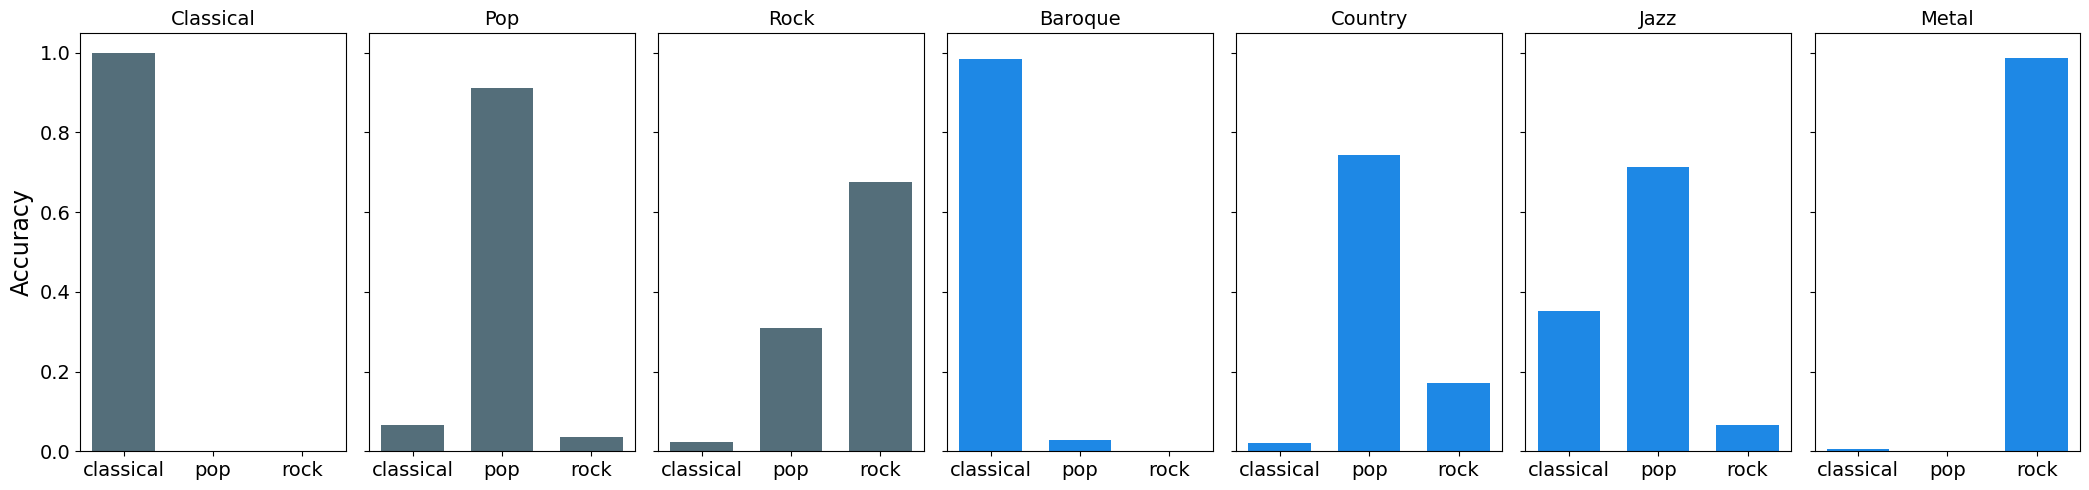

In [6]:
import matplotlib.pyplot as plt

# Create a figure and a set of subplots
fig, axes = plt.subplots(1, len(genres_to_analyze), figsize=(len(genres_to_analyze)*3, 5), sharey=True)

# Plot each genre's classification distribution
for i, genre in enumerate(genres_to_analyze):
    if genre in only_genres:
        color = "#546E7A"
    else:
        color = "#1E88E5"

    data = acc_genre[genre]
    axes[i].bar(data.keys(), data.values(), width=0.7, color=color)
    axes[i].set_title(genre.title(), fontsize=14)
    axes[i].tick_params(axis='both', which='major', labelsize=14)
    if i == 0:
        axes[i].set_ylabel('Accuracy', fontsize=17)

#plt.savefig("genre_accuracy.svg")
plt.tight_layout()
plt.show()